# Review NLP Analysis
### Analysis for Revolut, Klarna, Wise, Starling, Monzo, Lloyds, NatWest, Barclays, HSBC, Tide and ANNA Bank mobile app reviews


Loads `data/reviews_all.csv` (the combined scrape output), cleans the review text, scores sentiment
with **VADER**, and tags each review into functional product-issue buckets (KYC/Onboarding, Card
Declines, Transfer Latency, UI/UX Bug, Customer Support Friction, and a few more) using a rule-based
keyword classifier.

**Environment.** Run with the `fintech-app-reviews` kernel (same venv as the scraper notebook):
```bash
.venv/bin/pip install vaderSentiment
```

In [1]:
import html
import os
import re

import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option("display.max_colwidth", 100)

DATA_DIR = "data"
IN_PATH  = os.path.join(DATA_DIR, "reviews_all.csv")
OUT_PATH = os.path.join(DATA_DIR, "reviews_analyzed.csv")

## 1. Load reviews

Pulls `content` (the review text), rating, app, platform and timestamp out of the combined scrape
output. Rows with no text at all are dropped up front — VADER and the keyword tagger both need text
to work with.

In [2]:
df = pd.read_csv(IN_PATH)
df["reviewed_at"] = pd.to_datetime(df["reviewed_at"], utc=True, errors="coerce")

before = len(df)
df = df.dropna(subset=["content"]).copy()
df = df[df["content"].str.strip().str.len() > 0].copy()
print(f"Loaded {before} rows, {len(df)} have non-empty review text")

df[["platform", "app", "score", "content"]].head()

Loaded 35930 rows, 35930 have non-empty review text


,platform,app,score,content
0,google_play,Revolut,5,great app
1,google_play,Revolut,4,excellent
2,google_play,Revolut,5,"Been using for many years, great experience till now, everything is easy to setup and convenient"
3,google_play,Revolut,1,blocked account without any explanation after 9 years of usage
4,google_play,Revolut,5,great app.


## 2. Clean review text

Strips the noise that isn't sentiment- or topic-bearing: HTML entities (`&amp;` etc., which the iOS
RSS feed sometimes leaves in), URLs, emoji, and repeated whitespace. Case and punctuation are
otherwise left alone — VADER uses capitalization ("AWFUL") and punctuation ("!!!") as intensity
signals, so lowercasing before scoring would throw away information.

Rows that clean down to nothing (pure emoji, a stray URL, "...") are dropped as noise.

In [3]:
URL_RE   = re.compile(r"http\S+|www\.\S+")
HTML_RE  = re.compile(r"<[^>]+>")
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001FAFF"   # symbols, pictographs, emoticons, transport
    "\U00002600-\U000027BF"   # misc symbols & dingbats
    "\U0001F1E6-\U0001F1FF"   # regional indicators (flags)
    "\U00002190-\U000021FF"   # arrows
    "\U00002B00-\U00002BFF"   # misc symbols/arrows
    "]+",
    flags=re.UNICODE,
)
WS_RE = re.compile(r"\s+")


def clean_text(text):
    if not isinstance(text, str):
        return ""
    t = html.unescape(text)
    t = URL_RE.sub(" ", t)
    t = HTML_RE.sub(" ", t)
    t = EMOJI_RE.sub(" ", t)
    t = WS_RE.sub(" ", t).strip()
    return t


df["clean_content"] = df["content"].map(clean_text)

before = len(df)
df = df[df["clean_content"].str.contains(r"[A-Za-z0-9]", regex=True, na=False)].copy()
df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} rows that cleaned down to no real text; {len(df)} remain")

df[["content", "clean_content"]].sample(5, random_state=0)

Dropped 188 rows that cleaned down to no real text; 35742 remain


,content,clean_content
27021,"trying to set up my mortgage account, need to enter the account number from the email, can't pas...","trying to set up my mortgage account, need to enter the account number from the email, can't pas..."
24684,easy to use and extremely informative,easy to use and extremely informative
7694,great experience,great experience
4226,nice and easy,nice and easy
35147,App | Excellent service,App | Excellent service


## 3. VADER sentiment scoring

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon/rule-based sentiment model tuned
for short, informal text — a good fit for app store reviews. For each review it returns `neg`/`neu`/`pos`
proportions and a single normalized `compound` score in `[-1, 1]`.

Reviews are labeled using VADER's own documented thresholds: `compound >= 0.05` → positive,
`compound <= -0.05` → negative, otherwise neutral.

In [4]:
analyzer = SentimentIntensityAnalyzer()

vader_scores = pd.DataFrame(list(df["clean_content"].apply(analyzer.polarity_scores)))
vader_scores = vader_scores.add_prefix("vader_").reset_index(drop=True)
df = pd.concat([df.reset_index(drop=True), vader_scores], axis=1)


def label_sentiment(compound):
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"


df["vader_sentiment"] = df["vader_compound"].map(label_sentiment)

print(df["vader_sentiment"].value_counts())
print("\nMean compound score by star rating:")
print(df.groupby("score", observed=True)["vader_compound"].mean().round(3))

vader_sentiment
positive    26097
negative     5557
neutral      4088
Name: count, dtype: int64

Mean compound score by star rating:
score
1   -0.185
2   -0.048
3    0.085
4    0.380
5    0.562
Name: vader_compound, dtype: float64


## 4. Categorize into functional product buckets

There's no labeled training set here, so categorization is a transparent **rule-based keyword/phrase
classifier** rather than a trained model: each bucket is a set of regex patterns tuned to how people
actually phrase these complaints in fintech app reviews (e.g. "card declined", "still hasn't arrived",
"account frozen").

A review can match **multiple** buckets (a review can complain about both a card decline and slow
support). `categories` holds every bucket that matched; `primary_category` picks one for simple
grouping, using the fixed priority order below (harder operational failures — being locked out of your
money entirely — rank above softer ones like a UI bug). Reviews matching no complaint bucket fall back
to **General Praise** (high score + clearly positive sentiment, e.g. "great app", "excellent") or
**Uncategorized**.

Buckets, in priority order:
1. **Account Freeze/Restriction** — account or funds frozen, locked, restricted, closed
2. **Card Declines** — card/payment/transaction declined or blocked
3. **Transfer Latency** — money/transfers stuck, pending, slow to arrive
4. **KYC/Onboarding** — identity verification, document rejection, sign-up friction
5. **Login/Access Issues** — can't log in, 2FA, biometrics, password reset
6. **Customer Support Friction** — unresponsive/unhelpful support, chatbot loops, no way to reach a human
7. **Fees/Pricing** — hidden fees, poor exchange rates, overcharging
8. **UI/UX Bug** — crashes, glitches, broken screens, bad redesigns

In [5]:
# Priority order: index = tie-break rank used by primary_category() below.
#
# Each bucket generally needs BOTH word orders for its key verb/noun pair — reviewers phrase
# complaints either way ("account is locked" vs. "they locked my account", "card declined" vs.
# "keeps declining my card") — so patterns are duplicated in both directions rather than relying
# on one canonical phrasing.
CATEGORY_KEYWORDS = {
    "Account Freeze/Restriction": [
        r"account (was |is |got |been )?(frozen|freeze|locked|restrict\w*|suspend\w*|clos\w*|block\w*)",
        r"(lock\w*|froze|frozen|clos\w*|restrict\w*|suspend\w*|block\w*) (my |your |the )?account",
        r"funds? (are|were|is|got|being) (frozen|locked|held|on hold)",
        r"blocked (my|the) account",
        r"locked (me )?out of my account",
        r"restricted my account",
        r"can.?t access my (money|funds|account)",
    ],
    "Card Declines": [
        r"card (was |is |keeps |got )?declin\w*",
        r"(payment|transaction|purchase) (was |is |keeps |got )?declin\w*",
        r"declin\w* (my |your |the )?(scheduled )?(card|payment|transaction|purchase)",
        r"card (isn.?t|is not|not) working",
        r"card (got |was )?block\w*",
        r"(block\w*|froze|frozen) (my |your |the )?(debit |credit )?card",
        r"declined (my |the )?(card|payment|transaction)",
        r"card (got |was )?rejected",
        r"contactless (isn.?t|not) working",
    ],
    "Transfer Latency": [
        r"transfer\w* (is |was |still |has been )?(pending|stuck|delayed|taking)",
        r"money (is |was |got )?stuck",
        r"still (hasn.?t|has not) arrived",
        r"(never|still) (arrived|made it|shown up|showed up|come through|gone through)",
        r"days? to (arrive|clear|process)",
        r"withdrawal (is |was )?pending",
        r"waiting (for|on) my money",
        r"slow (transfer|to transfer)",
        r"transfer (didn.?t|did not|never) (arrive|complete|go through)",
        r"pending for (days|weeks)",
    ],
    "KYC/Onboarding": [
        r"verif\w* (my |the )?(identity|account|document)",
        r"\bkyc\b",
        r"identity check",
        r"id document",
        r"\bselfie\b",
        r"proof of address",
        r"onboard\w*",
        r"sign ?up (process|was|is)",
        r"couldn.?t open (an |my )?account",
        r"documents? (were |was )?rejected",
    ],
    "Login/Access Issues": [
        r"can.?t log ?in",
        r"login (failed|error|issue|problem)",
        r"(logged|kicked) (me )?out",
        r"two.?factor",
        r"\b2fa\b",
        r"password reset",
        r"pin (isn.?t|not) working",
        r"face ?id (isn.?t|not) working",
        r"biometric\w*",
    ],
    "Customer Support Friction": [
        r"customer (service|support)",
        r"support team",
        r"no response",
        r"can.?t reach (anyone|support|them)",
        r"\bchatbot\b",
        r"live chat",
        r"waited (days|weeks|hours)",
        r"unhelpful",
        r"no phone number",
        r"no one (replies|responds|answers)",
        r"ignored my (email|message)",
    ],
    "Fees/Pricing": [
        r"hidden fees?",
        r"charg\w* me",
        r"fees? (are|is|too|so) (high|expensive|much)",
        r"exchange rate",
        r"subscription (fee|cost)",
        r"monthly fee",
        r"overcharg\w*",
    ],
    "UI/UX Bug": [
        r"\bcrash\w*",
        r"\bbug\w*",
        r"\bglitch\w*",
        r"keeps? (crashing|freezing|glitching)",
        r"app (is |keeps )?broken",
        r"won.?t load",
        r"stopped working",
        r"update broke",
        r"blank screen",
        r"error message",
        r"force close",
    ],
}

CATEGORY_PATTERNS = {
    name: re.compile("|".join(patterns), re.IGNORECASE)
    for name, patterns in CATEGORY_KEYWORDS.items()
}


def tag_categories(text):
    return [name for name, pattern in CATEGORY_PATTERNS.items() if pattern.search(text)]


def primary_category(categories, score, compound):
    for name in CATEGORY_KEYWORDS:  # dict order = priority order
        if name in categories:
            return name
    if score >= 4 and compound >= 0.2:
        return "General Praise"
    return "Uncategorized"


df["categories"] = df["clean_content"].map(tag_categories)
df["primary_category"] = [
    primary_category(cats, score, comp)
    for cats, score, comp in zip(df["categories"], df["score"], df["vader_compound"])
]
df["n_categories"] = df["categories"].map(len)

df["primary_category"].value_counts()

primary_category
General Praise                22464
Uncategorized                 10610
Customer Support Friction       885
UI/UX Bug                       610
Account Freeze/Restriction      430
Fees/Pricing                    342
Login/Access Issues             200
KYC/Onboarding                  130
Card Declines                    44
Transfer Latency                 27
Name: count, dtype: int64

## 5. Summary — where is each app bleeding?

Restricted to the complaint buckets (excludes `General Praise` and `Uncategorized`). For each
app x category: review volume, mean VADER compound, and the negative share (`vader_sentiment ==
"negative"`) — the last column is the closest thing to a pain-point severity ranking.

In [6]:
COMPLAINT_BUCKETS = list(CATEGORY_KEYWORDS.keys())
complaints = df[df["primary_category"].isin(COMPLAINT_BUCKETS)].copy()

summary = (
    complaints.groupby(["app", "primary_category"], observed=True)
    .agg(
        n_reviews=("vader_compound", "size"),
        mean_compound=("vader_compound", "mean"),
        negative_share=("vader_sentiment", lambda s: (s == "negative").mean()),
    )
    .round(3)
    .sort_values(["app", "n_reviews"], ascending=[True, False])
)
summary

n_reviews  mean_compound  negative_share
app       primary_category                                                    
ANNA Bank Customer Support Friction          10          0.624           0.100
          Account Freeze/Restriction          6         -0.513           0.833
          KYC/Onboarding                      2         -0.253           1.000
          UI/UX Bug                           2         -0.638           1.000
          Card Declines                       1         -0.153           1.000
...                                         ...            ...             ...
Wise      UI/UX Bug                          39         -0.111           0.564
          KYC/Onboarding                     29         -0.201           0.517
          Login/Access Issues                15          0.023           0.400
          Transfer Latency                   11         -0.018           0.455
          Card Declines                       6         -0.305           0.667

[78 rows x 3 columns]

In [7]:
# Same thing pivoted for a side-by-side app comparison per category
volume_pivot = pd.crosstab(complaints["primary_category"], complaints["app"])
volume_pivot["total"] = volume_pivot.sum(axis=1)
volume_pivot = volume_pivot.sort_values("total", ascending=False)
print("=== Complaint volume by category x app ===")
display(volume_pivot)

neg_share_pivot = complaints.pivot_table(
    index="primary_category", columns="app",
    values="vader_sentiment", aggfunc=lambda s: (s == "negative").mean(),
).round(3)
print("\n=== Negative-sentiment share by category x app ===")
display(neg_share_pivot.loc[volume_pivot.index])

print(f"\nMulti-label reviews (flagged with >1 category): {(df['n_categories'] > 1).sum()}")
print(f"Uncategorized (no complaint keyword match, not clearly positive): {(df['primary_category'] == 'Uncategorized').sum()}")

=== Complaint volume by category x app ===


app,ANNA Bank,Barclays,HSBC,Klarna,Lloyds,Monzo,NatWest,Revolut,Starling,Tide,Wise,total
primary_category,,,,,,,,,,,,
Customer Support Friction,10,48,52,171,37,92,48,120,122,32,153,885
UI/UX Bug,2,153,65,61,75,12,50,128,19,6,39,610
Account Freeze/Restriction,6,14,23,17,15,71,14,101,15,18,136,430
Fees/Pricing,1,0,4,31,1,6,2,86,11,0,200,342
Login/Access Issues,0,21,22,30,18,9,58,21,6,0,15,200
KYC/Onboarding,2,1,17,32,5,8,3,28,3,2,29,130
Card Declines,1,3,2,12,3,1,4,3,9,0,6,44
Transfer Latency,0,0,0,6,1,2,0,6,1,0,11,27



=== Negative-sentiment share by category x app ===


app,ANNA Bank,Barclays,HSBC,Klarna,Lloyds,Monzo,NatWest,Revolut,Starling,Tide,Wise
primary_category,,,,,,,,,,,
Customer Support Friction,0.100,0.375,0.442,0.561,0.351,0.359,0.333,0.433,0.180,0.594,0.477
UI/UX Bug,1.000,0.431,0.462,0.459,0.507,0.583,0.460,0.367,0.263,0.500,0.564
Account Freeze/Restriction,0.833,0.429,0.652,0.588,0.600,0.648,0.500,0.614,0.533,0.778,0.603
Fees/Pricing,1.000,NaN,0.500,0.484,0.000,0.000,0.500,0.163,0.091,NaN,0.090
Login/Access Issues,NaN,0.381,0.545,0.367,0.611,0.556,0.466,0.524,0.000,NaN,0.400
KYC/Onboarding,1.000,1.000,0.706,0.500,0.600,0.500,0.333,0.429,0.333,0.500,0.517
Card Declines,1.000,0.667,0.500,0.333,0.667,1.000,0.500,0.333,0.444,NaN,0.667
Transfer Latency,NaN,NaN,NaN,0.500,0.000,0.500,NaN,0.500,0.000,NaN,0.455



Multi-label reviews (flagged with >1 category): 197
Uncategorized (no complaint keyword match, not clearly positive): 10610


## 6. Save the analyzed dataset

Writes every review plus its cleaned text, VADER scores/label, and category tags to
`data/reviews_analyzed.csv`. `categories` is serialized as a `;`-joined string for CSV round-tripping.

In [8]:
out_cols = [
    "platform", "app", "review_id", "user_name", "score", "reviewed_at",
    "content", "clean_content",
    "vader_neg", "vader_neu", "vader_pos", "vader_compound", "vader_sentiment",
    "categories", "primary_category", "n_categories",
]

out_df = df[out_cols].copy()
out_df["categories"] = out_df["categories"].map(lambda cats: ";".join(cats))

out_df.to_csv(OUT_PATH, index=False)
print(f"Saved {len(out_df)} rows to {OUT_PATH}")

Saved 35742 rows to data/reviews_analyzed.csv


## 7. Chart — complaint volume by category, split by app

One measure (review count), split by category (magnitude) and app (identity) — a grouped horizontal
bar chart, one hue per app from a fixed categorical palette (never cycled), sorted by total volume so the
biggest pain points read top-to-bottom. Covers all **11 apps** in `reviews_all.csv` (ANNA Bank, Barclays,
HSBC, Klarna, Lloyds, Monzo, NatWest, Revolut, Starling, Tide, Wise).


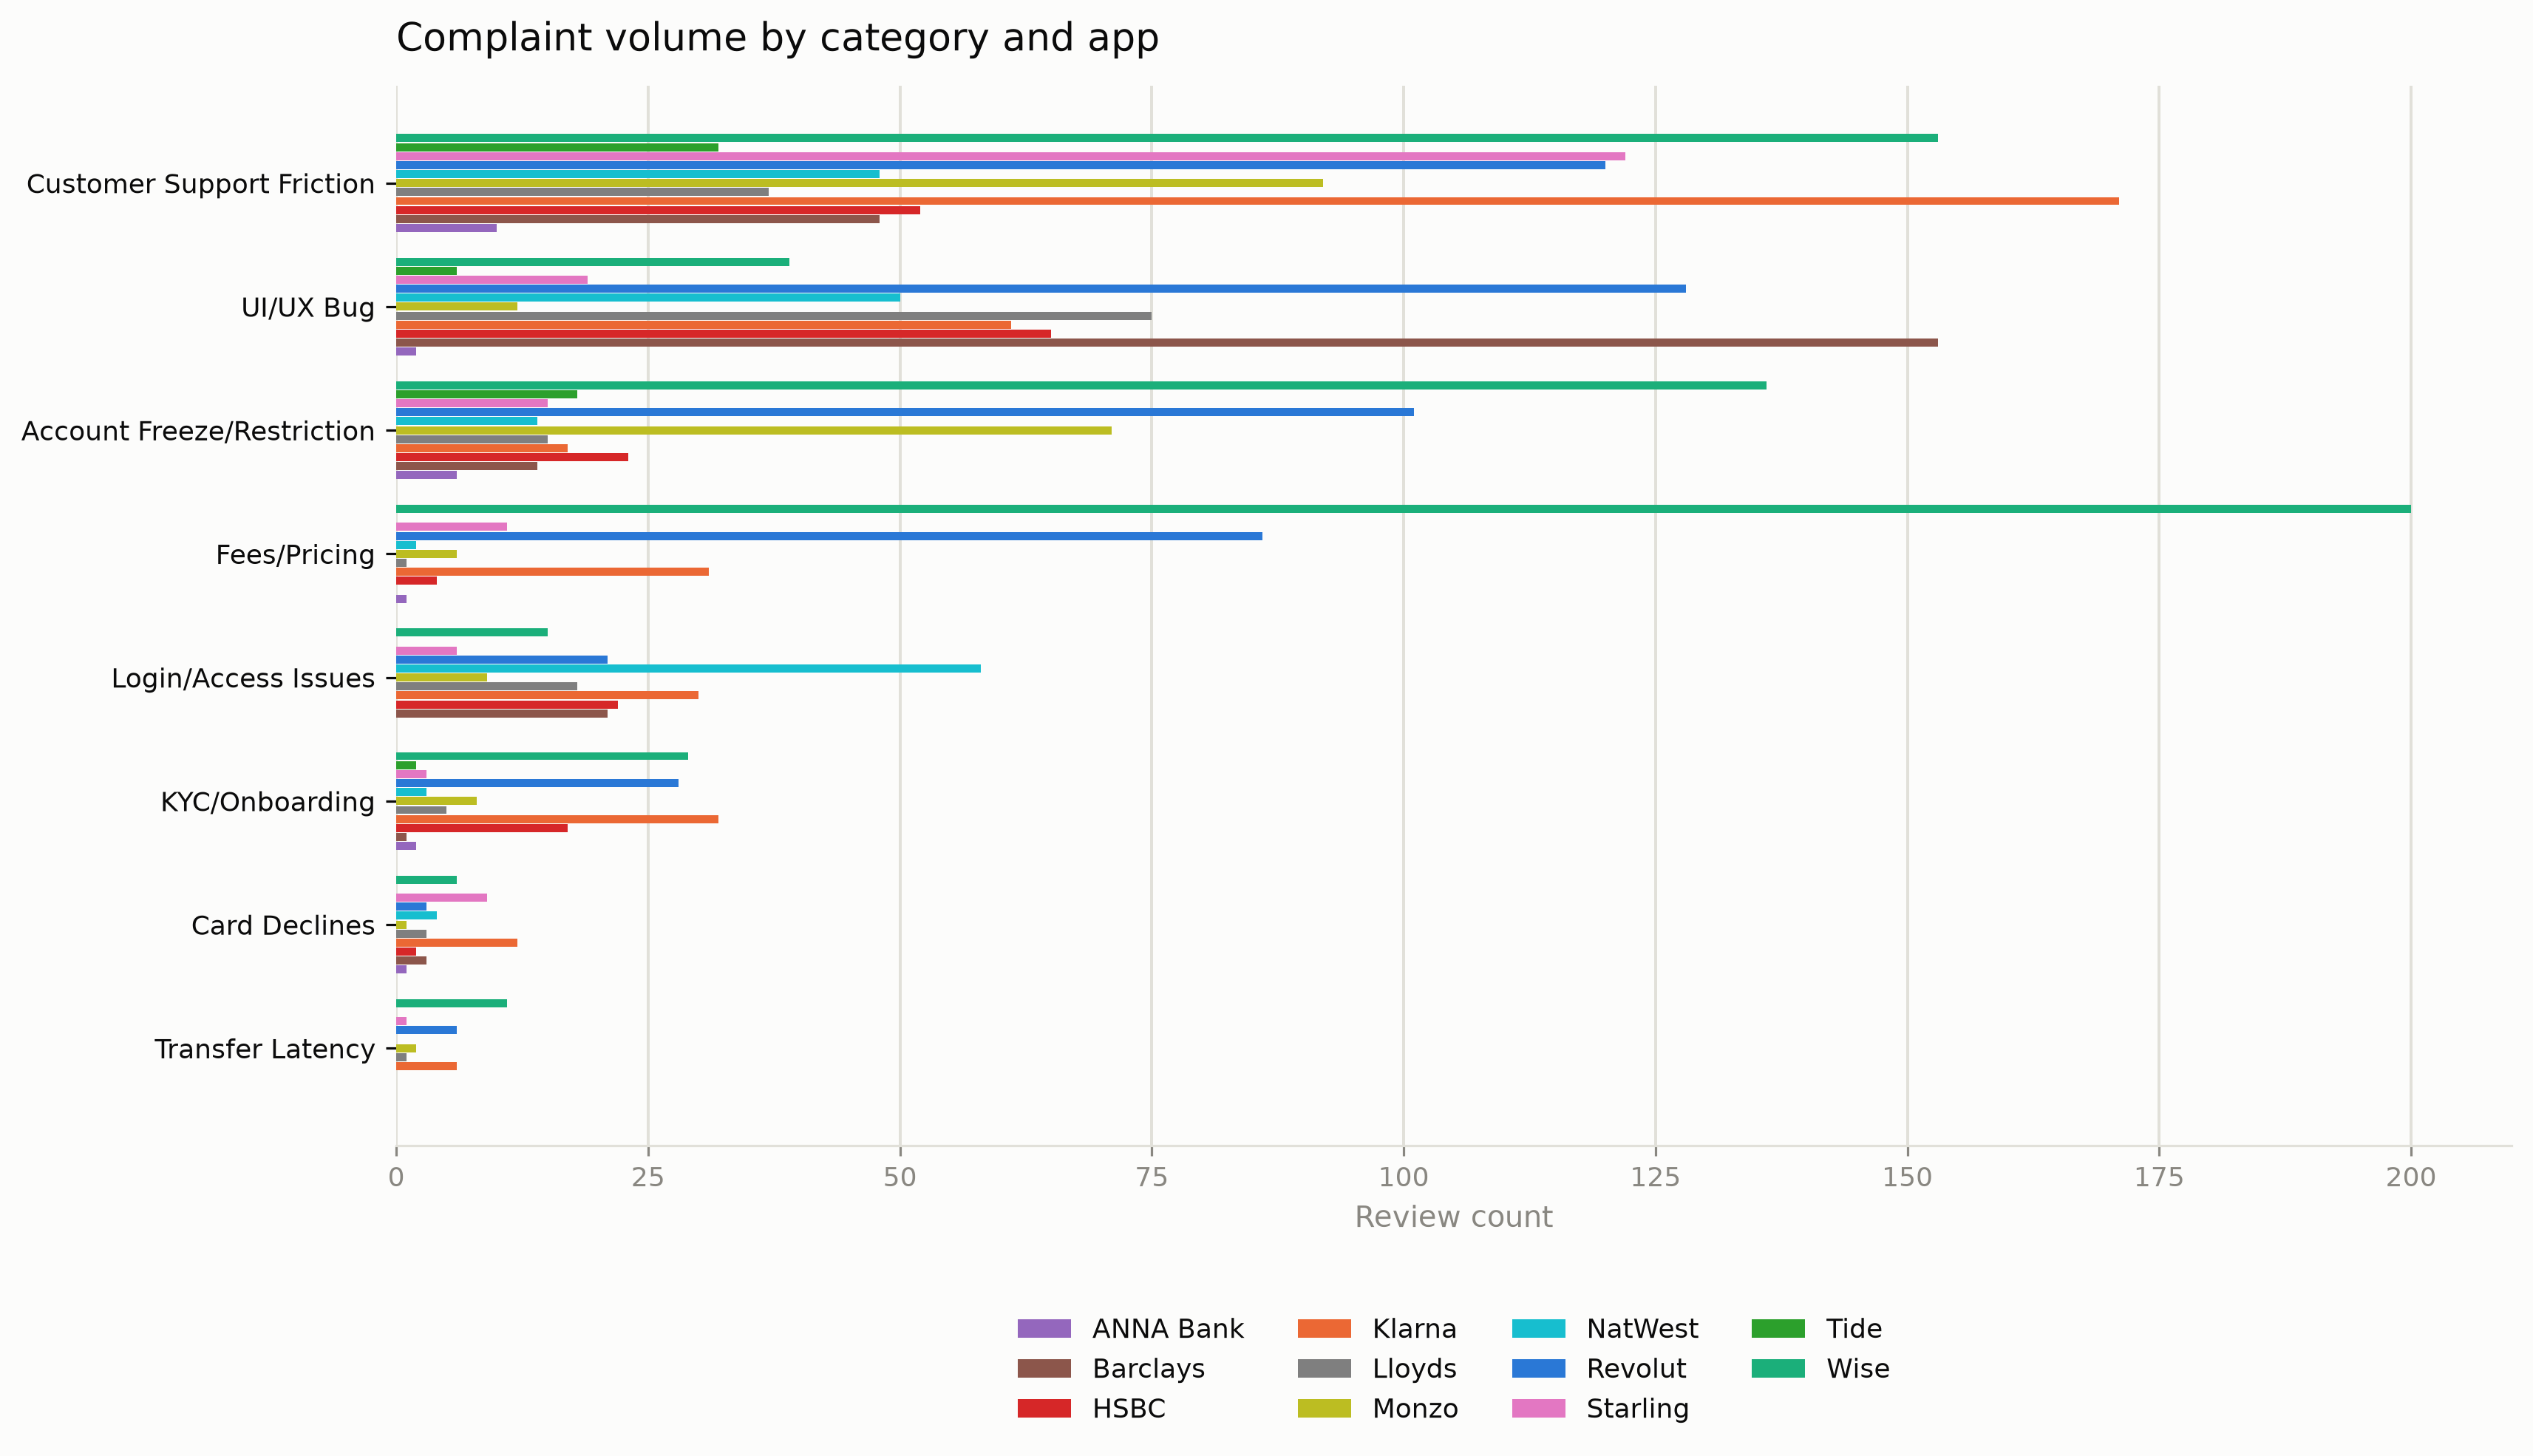

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Fixed categorical palette (never cycled) — extended to all 11 apps.
# Original 3 hexes kept stable; 8 new hexes from a distinct qualitative palette.
APP_COLORS = {
    "ANNA Bank": "#9467bd",
    "Barclays":  "#8c564b",
    "HSBC":      "#d62728",
    "Klarna":    "#eb6834",  # original
    "Lloyds":    "#7f7f7f",
    "Monzo":     "#bcbd22",
    "NatWest":   "#17becf",
    "Revolut":   "#2a78d6",  # original
    "Starling":  "#e377c2",
    "Tide":      "#2ca02c",
    "Wise":      "#1baf7a",  # original
}
INK        = "#0b0b0b"
MUTED      = "#898781"
GRIDLINE   = "#e1e0d9"
SURFACE    = "#fcfcfb"

# Keep only apps that actually appear in the pivot (robust to filtering)
apps = [a for a in APP_COLORS if a in volume_pivot.columns]
# Fallback: if a new app appears that isn't in APP_COLORS yet, append it
for col in volume_pivot.columns:
    if col not in apps and col != "total":
        apps.append(col)
categories = volume_pivot.index.tolist()[::-1]  # reverse so highest-volume sits at top of barh
y = np.arange(len(categories))
bar_h = 0.8 / len(apps)

fig, ax = plt.subplots(figsize=(12, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for i, app in enumerate(apps):
    vals = volume_pivot.loc[categories, app].values
    offset = (i - (len(apps) - 1) / 2) * bar_h
    color = APP_COLORS.get(app, "#333333")
    ax.barh(y + offset, vals, height=bar_h * 0.9, color=color, label=app)

ax.set_yticks(y)
ax.set_yticklabels(categories, color=INK, fontsize=9)
ax.set_xlabel("Review count", color=MUTED, fontsize=10)
ax.tick_params(axis="x", colors=MUTED, labelsize=9)
ax.tick_params(axis="y", colors=INK)
ax.grid(axis="x", color=GRIDLINE, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRIDLINE)

ax.set_title("Complaint volume by category and app", color=INK, fontsize=13, loc="left", pad=12)
# 11 hues need more room than lower-right; place legend below the axes
ax.legend(ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.14), frameon=False, labelcolor=INK, fontsize=9)

plt.tight_layout()
plt.show()
